# **Fase 2: Transformation**

Estudiante: Maria Camila Navarrete Pinzón

Código: 2294353

Fecha: 07 febrero, 2026

# Notebook 4: Transformaciones avanzadas

**Objetivo**: Aplicar transformaciones avanzadas para mejorar el desempeño del modelo.

**Actividades**:
- Normalizar features numéricas con StandardScaler
- Aplicar PCA para reducción de dimensionalidad
- Construir pipeline completo
- Comparar resultados con y sin transformaciones


## 1. Configuración de SparkSession

Se crea una sesión de spark configurada para ejecutarse en modo local, asignando memoria al driver.

In [2]:
# %%
from pyspark.sql import SparkSession
from pyspark.ml.feature import StandardScaler, PCA, VectorAssembler
from pyspark.ml import Pipeline, PipelineModel
from pyspark.sql.functions import col

# %%
spark = SparkSession.builder \
    .appName("SECOP_Transformaciones") \
    .master("local[*]") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/12 23:53:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/12 23:53:15 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/02/12 23:53:25 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


## 2. Carga de datos

In [3]:
df = spark.read.parquet("/opt/spark-data/processed/secop_features.parquet")
print(f"Registros: {df.count():,}")
print(f"Columnas: {len(df.columns)}")

Registros: 52,248
Columnas: 20


## 3. Reto 1 - ¿Por qué normalizar?

**Pregunta de análisis**: Examina los valores en `features_raw`. ¿Hay features con escalas muy diferentes?

**Instrucciones**:
- Toma una muestra de 5 registros
- Convierte `features_raw` a array y examina los valores
- Identifica si hay features con magnitudes muy diferentes (ej: 0.01 vs 1000000)
- Explica por qué esto es un problema para ML

In [5]:
sample = df.select("features_raw").limit(5).collect()

print("Muestra de features (primeros 10 valores):\n")
for i, row in enumerate(sample, 1):
    features_array = row["features_raw"].toArray()
    print(f"Registro {i}: {features_array[:10]}")


Muestra de features (primeros 10 valores):

Registro 1: [99960000.        0.        0.        0.        0.        0.        0.
        0.        0.        0.]
Registro 2: [2.25034579e+08 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.00000000e+00
 0.00000000e+00 0.00000000e+00]
Registro 3: [2.5e+06 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 1.0e+00 0.0e+00 0.0e+00
 0.0e+00]
Registro 4: [6.0596344e+07 1.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
Registro 5: [3.4875e+06 0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00]


Se observan diferencias grandes en las magnitudes de las features (algunas muy pequeñas y otras muy grandes).
Esto es un problema porque muchos algoritmos de ML se ven dominados por las variables con valores más altos, haciendo que las features pequeñas pierdan importancia. Normalizar permite que todas las variables contribuyan de forma equilibrada al modelo.

### 3.1 StandardScaler

**Concepto**: StandardScaler centra los datos (media=0) y escala (std=1)

**z = (x - μ) / σ**

**Crea un StandardScaler**
- inputCol: "features_raw" (del notebook anterior)
- outputCol: "features_scaled"
- withMean: False (requerido para vectores sparse)
- withStd: True (normalizar por desviación estándar)

In [6]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=False,
    withStd=True
)

print("✓ StandardScaler creado")

scaler_model = scaler.fit(df)
df_scaled = scaler_model.transform(df)

print("✓ Features escaladas")
print("\nColumnas nuevas:")
print(df_scaled.columns[-3:])


✓ StandardScaler creado


✓ Features escaladas

Columnas nuevas:
['estado_contrato_vec', 'features_raw', 'features_scaled']


## 4. Reto 2 - Comparar antes y después de escalar
 
**Objetivo**: Verificar que el escalado funcionó correctamente

**Instrucciones**:
- Calcula estadísticas del vector `features_raw`
- Calcula estadísticas del vector `features_scaled`
- Compara las magnitudes

In [7]:
import pandas as pd
import numpy as np

sample_df = df_scaled.select("features_raw", "features_scaled").limit(1000).toPandas()

raw_matrix = np.array([row["features_raw"].toArray() for row in sample_df.to_dict("records")])
scaled_matrix = np.array([row["features_scaled"].toArray() for row in sample_df.to_dict("records")])

print("ANTES (features_raw):")
print(f"  Min: {raw_matrix.min():.2f}")
print(f"  Max: {raw_matrix.max():.2f}")
print(f"  Mean: {raw_matrix.mean():.2f}")
print(f"  Std: {raw_matrix.std():.2f}")

print("\nDESPUÉS (features_scaled):")
print(f"  Min: {scaled_matrix.min():.2f}")
print(f"  Max: {scaled_matrix.max():.2f}")
print(f"  Mean: {scaled_matrix.mean():.2f}")
print(f"  Std: {scaled_matrix.std():.2f}")


ANTES (features_raw):
  Min: 0.00
  Max: 322709746890.00
  Mean: 7658106.04
  Std: 1289521629.13

DESPUÉS (features_scaled):
  Min: 0.00
  Max: 228.58
  Mean: 0.18
  Std: 1.31


Los resultados muestran que antes del escalado las features tenían magnitudes extremadamente desbalanceadas, con valores máximos muy altos y una desviación estándar enorme, lo que hacía que algunas variables dominaran completamente al resto. Después de aplicar StandardScaler las variables quedan en una escala mucho más homogénea con media cercana a cero y desviación estándar cercana a uno.

## 5. Reto 3 - PCA para Reducción de Dimensionalidad

**Pregunta**: Si tu vector de features tiene 50 dimensiones, ¿cuántos componentes principales deberías conservar?

**Opciones**:

- A) Todos (50)
- B) La mitad (25)
- C) Los que expliquen 95% de la varianza
- D) Solo 5-10 componentes

**Justifica tu respuesta**

C. Conservar los componentes que expliquen al menos el 95% de la varianza, ya que permite reducir dimensionalidad sin perder demasiada información importante.

### 5.1 Configura PCA

- inputCol: "features_scaled" (ya normalizadas)
- outputCol: "features_pca"
- k: número de componentes (experimenta con diferentes valores)

In [8]:
sample_vec = df_scaled.select("features_scaled").first()[0]
num_features = len(sample_vec)
print(f"Número total de features: {num_features}")

k_components = min(10, num_features)

pca = PCA(
    k=k_components,
    inputCol="features_scaled",
    outputCol="features_pca"
)

print(f"✓ PCA configurado con k={k_components}")


Número total de features: 63
✓ PCA configurado con k=10


In [9]:
pca_model = pca.fit(df_scaled)
df_pca = pca_model.transform(df_scaled)

print("✓ PCA aplicado")
print(f"Dimensión original: {num_features}")
print(f"Dimensión reducida: {k_components}")


26/02/13 00:27:04 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


✓ PCA aplicado
Dimensión original: 63
Dimensión reducida: 10


## 6. Reto 4 - Analizar Varianza Explicada

**Objetivo**: Entender cuánta información conservamos con PCA

**Pregunta**: ¿Qué porcentaje de varianza explican los k componentes?

In [10]:
explained_variance = pca_model.explainedVariance

print("\nVarianza explicada por componente")
for i, var in enumerate(explained_variance):
    print(f"Componente {i+1}: {var*100:.2f}%")

cumulative_variance = 0
print("\nVarianza acumulada:")
for i, var in enumerate(explained_variance):
    cumulative_variance += var
    print(f"Acumulada hasta PC{i+1}: {cumulative_variance*100:.2f}%")



Varianza explicada por componente
Componente 1: 3.52%
Componente 2: 2.68%
Componente 3: 2.21%
Componente 4: 2.11%
Componente 5: 1.95%
Componente 6: 1.93%
Componente 7: 1.87%
Componente 8: 1.85%
Componente 9: 1.80%
Componente 10: 1.74%

Varianza acumulada:
Acumulada hasta PC1: 3.52%
Acumulada hasta PC2: 6.20%
Acumulada hasta PC3: 8.42%
Acumulada hasta PC4: 10.52%
Acumulada hasta PC5: 12.47%
Acumulada hasta PC6: 14.40%
Acumulada hasta PC7: 16.27%
Acumulada hasta PC8: 18.13%
Acumulada hasta PC9: 19.93%
Acumulada hasta PC10: 21.67%


**Pregunta:** ¿Cuántos componentes necesitas para explicar al menos 80% de la varianza?

 Para que la varianza acumulada sea por lo menos de 80% se necesitan más de 10 componentes, ya que los primeros 10 solo explican el 21%. Para que la varianza acumulada sea 80% serán necesarios al rededor de 46 componentes. 

## 7. Reto 5 - Pipeline Completo

**Objetivo**: Integrar todas las transformaciones en un solo pipeline

**Orden correcto**:
- Cargar pipeline de feature engineering (notebook 03)
- Agregar StandardScaler
- Agregar PCA

**Pregunta** ¿Por qué es importante este ordenes?

In [11]:
feature_pipeline = PipelineModel.load("/opt/spark-data/processed/feature_pipeline")
print("✓ Pipeline de features cargado")

complete_pipeline_stages = list(feature_pipeline.stages) + [scaler, pca]

complete_pipeline = Pipeline(stages=complete_pipeline_stages)

print(f"\n✓ Pipeline completo con {len(complete_pipeline_stages)} stages:")
for i, stage in enumerate(complete_pipeline_stages):
    print(f"  {i+1}. {type(stage).__name__}")


✓ Pipeline de features cargado

✓ Pipeline completo con 9 stages:
  1. StringIndexerModel
  2. StringIndexerModel
  3. StringIndexerModel
  4. OneHotEncoderModel
  5. OneHotEncoderModel
  6. OneHotEncoderModel
  7. VectorAssembler
  8. StandardScaler
  9. PCA


Es importante porque primero se construyen las features, luego se normalizan y finalmente se aplica PCA. Este asume que todas las variables están en la misma escala; si se aplica antes del escalado, los resultados serían invalidos.

## 8. Reto Bonus 1 - Experimentar con diferentes valores de k

**Objetivo**: Encontrar el número óptimo de componentes PCA

**Instrucciones**:
- Prueba con k = [5, 10, 15, 20]
- Para cada k, calcula la varianza acumulada
- Grafica k vs varianza explicada
- Decide cuál es el mejor k (balance entre reducción y información)

In [20]:
import matplotlib.pyplot as plt
k_values = [10, 25, 40, 46, 50]
explained_vars = []
print("\nExperimentando con diferentes valores de k")
for k in k_values:
    k_eff = min(k, num_features)  # por si k > número real de features
    pca_temp = PCA(
        k=k_eff,
        inputCol="features_scaled",
        outputCol="temp_pca"
    )
    
    pca_temp_model = pca_temp.fit(df_scaled)
    cumulative_var = float(sum(pca_temp_model.explainedVariance))
    explained_vars.append(cumulative_var)
    print(f"k={k_eff}: {cumulative_var*100:.2f}% de varianza explicada")


Experimentando con diferentes valores de k
k=10: 21.67% de varianza explicada
k=25: 46.52% de varianza explicada
k=40: 70.50% de varianza explicada
k=46: 79.89% de varianza explicada
k=50: 86.04% de varianza explicada


Jugando con diferentes valores de k, se puede evidenciar que para que la varianza acumulada sea 80%, la cantidad de componentes debe ser exactamente 46. 

### 8.1 Graficar

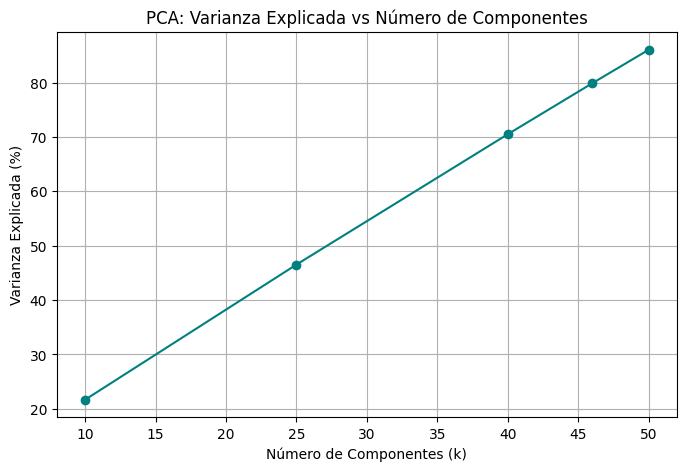

In [24]:

plt.figure(figsize=(8, 5))
plt.plot(k_values, [v * 100 for v in explained_vars], marker='o', color='teal')
plt.xlabel('Número de Componentes (k)')
plt.ylabel('Varianza Explicada (%)')
plt.title('PCA: Varianza Explicada vs Número de Componentes')
plt.grid(True)


El gráfico muestra que a medida que aumenta el número de componentes principales la varianza explicada crece de forma progresiva pero con rendimientos decrecientes. Con alrededor de 25 componentes se explica cerca del 45 % de la varianza, mientras que al llegar a 40–45 componentes se supera aproximadamente el 70–80 %, y con 50 componentes se alcanza cerca del 85 %. Esto indica que una parte importante de la información está concentrada en los primeros componentes, y que a partir de cierto punto añadir más dimensiones aporta ganancias marginales.

## 9. ML



In [25]:
if "valor_del_contrato_num" in df_pca.columns:
    df_ml_ready = df_pca.select(
        "features_pca",
        col("valor_del_contrato_num").alias("label")
    )
else:
    print("ADVERTENCIA: No se encontró columna de valor. Usando todas las columnas.")
    df_ml_ready = df_pca


In [26]:
output_path = "/opt/spark-data/processed/secop_ml_ready.parquet"
df_ml_ready.write.mode("overwrite").parquet(output_path)
print(f"\n✓ Dataset ML-ready guardado en: {output_path}")



✓ Dataset ML-ready guardado en: /opt/spark-data/processed/secop_ml_ready.parquet


## 10. Preguntas de Reflexión

1. ¿Por qué StandardScaler usa withMean=False?
   
Porque los vectores sparse no soportan centrado sin volverse densos, lo que rompería eficiencia y memoria.


2. ¿Cuándo NO deberías usar PCA?

Cuando el modelo ya maneja bien alta dimensionalidad (ej. árboles).


3. Si tienes 100 features y aplicas PCA con k=10, ¿perdiste información?

Sí, pero idealmente solo información poco relevante ya que su varianza sería baja.


4. ¿Qué ventaja tiene aplicar StandardScaler ANTES de PCA?

Evita que variables con magnitudes grandes dominen los componentes principales.


In [27]:

print("Resumen de transformaciones")

print(f"✓ Features normalizadas con StandardScaler")
print(f"✓ Dimensionalidad reducida: {num_features} → {k_components}")
print(f"✓ Varianza explicada: {sum(pca_model.explainedVariance)*100:.2f}%")
print(f"✓ Dataset listo para entrenar modelos")


Resumen de transformaciones
✓ Features normalizadas con StandardScaler
✓ Dimensionalidad reducida: 63 → 10
✓ Varianza explicada: 21.67%
✓ Dataset listo para entrenar modelos


In [28]:

spark.stop()